In [12]:
import pandas as pd

In [13]:
df=pd.read_csv("weight-height.csv")

In [14]:
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


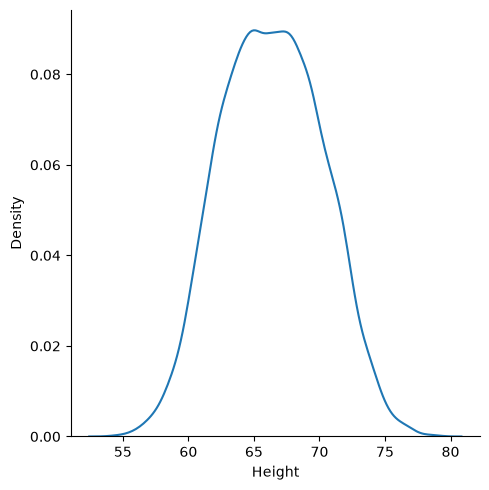

In [15]:
import seaborn as sns
sns.displot(df["Height"],kind="kde") # normally distributed

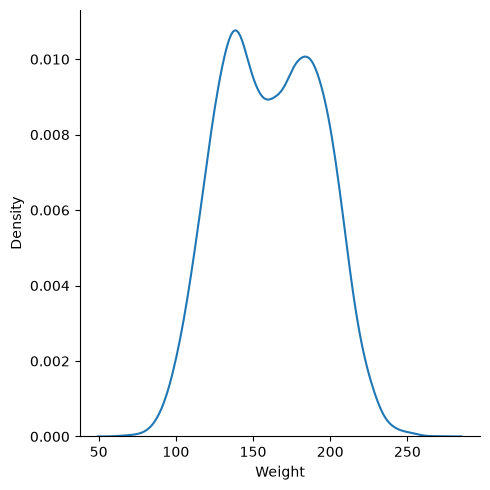

In [16]:
sns.displot(df["Weight"],kind="kde")

In [17]:
# calculating percentile

import numpy as np
lowerPerc=np.percentile(df["Weight"],1)
higherPerc=np.percentile(df["Weight"],99)

In [18]:
# viewing outliers
outliers=df[
    (df["Weight"]<lowerPerc) |
    (df["Weight"]>higherPerc)
]

outliers

,Gender,Height,Weight
0,Male,73.847017,241.893563
23,Male,75.205974,228.761781
82,Male,73.826127,237.916736
190,Male,76.709835,235.035419
191,Male,72.571121,230.560535
...,...,...,...
9761,Female,56.975279,90.341784
9775,Female,60.025950,87.035416
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957


In [19]:
# trimming
new_df=df[
    (df["Weight"]>=lowerPerc) &
    (df["Weight"]<=higherPerc)
]

new_df

,Gender,Height,Weight
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
5,Male,67.253016,152.212156
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


CAPPING

In [20]:
df["Weight_Capped"]=np.where(
    df["Weight"]>higherPerc,
    higherPerc,
    np.where(
        df["Weight"]<lowerPerc,
        lowerPerc,
        df["Weight"]
    )
)

In [21]:
df

,Gender,Height,Weight,Weight_Capped
0,Male,73.847017,241.893563,227.437370
1,Male,68.781904,162.310473,162.310473
2,Male,74.110105,212.740856,212.740856
3,Male,71.730978,220.042470,220.042470
4,Male,69.881796,206.349801,206.349801
...,...,...,...,...
9995,Female,66.172652,136.777454,136.777454
9996,Female,67.067155,170.867906,170.867906
9997,Female,63.867992,128.475319,128.475319
9998,Female,69.034243,163.852461,163.852461
